<a href="https://colab.research.google.com/github/ervaishnavisutar-del/ddaex/blob/main/Shopping_Trends_updated_Ex_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np


In [26]:
df=pd.read_csv("shopping_trends_updated.csv")


In [27]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [28]:
df.shape


(3900, 18)

In [29]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
3895,False
3896,False
3897,False
3898,False


In [30]:
df.drop_duplicates(inplace=True)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [32]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [33]:


df["Age_Group"]=pd.cut(
    df["Age"],
    bins=[0,25,40,60,100],
    labels=["Young","Adult","Middle","Senior"]
)
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age_Group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Middle
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly,Adult
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly,Middle
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly,Middle
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly,Middle


In [34]:

def Amount_Category (amount):
    if amount <= 30:
        return"Low"
    elif amount <= 70:
        return "Medium"
    else:
      return"High"
df["Amount_Category"]=df["Purchase Amount (USD)"].apply(Amount_Category)
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age_Group,Amount_Category
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Middle,Medium
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young,Medium
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle,High
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young,High
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly,Adult,Low
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly,Middle,Medium
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly,Middle,Medium
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly,Middle,High


In [35]:

amount_encoded=pd.get_dummies(df["Amount_Category"])
amount_encoded

,High,Low,Medium
0,False,False,True
1,False,False,True
2,True,False,False
3,True,False,False
4,False,False,True
...,...,...,...
3895,False,True,False
3896,False,False,True
3897,False,False,True
3898,True,False,False


In [36]:

season_encoded=pd.get_dummies(df["Season"])
season_encoded

,Fall,Spring,Summer,Winter
0,False,False,False,True
1,False,False,False,True
2,False,True,False,False
3,False,True,False,False
4,False,True,False,False
...,...,...,...,...
3895,False,False,True,False
3896,False,True,False,False
3897,False,True,False,False
3898,False,False,True,False


In [37]:




df["Combined"]=df["Purchase Amount (USD)"]/df["Age"]
df["Combined"]

,Combined
0,0.963636
1,3.368421
2,1.460000
3,4.285714
4,1.088889
...,...
3895,0.700000
3896,0.942308
3897,0.717391
3898,1.750000


In [38]:

df["Customer_Score"]=df["Review Rating"]*df["Previous Purchases"]
df["Customer_Score"]

,Customer_Score
0,43.4
1,6.2
2,71.3
3,171.5
4,83.7
...,...
3895,134.4
3896,184.5
3897,69.6
3898,91.2


In [39]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df["Age_Scaled"]=scaler.fit_transform(df[["Age"]])
df["PurchaseAmount_Scaled"]=scaler.fit_transform(df[["Purchase Amount (USD)"]])
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age_Group,Amount_Category,Combined,Customer_Score,Age_Scaled,PurchaseAmount_Scaled
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,14,Venmo,Fortnightly,Middle,Medium,0.963636,43.4,0.711538,0.4125
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,2,Cash,Fortnightly,Young,Medium,3.368421,6.2,0.019231,0.5500
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,23,Credit Card,Weekly,Middle,High,1.460000,71.3,0.615385,0.6625
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,49,PayPal,Weekly,Young,High,4.285714,171.5,0.057692,0.8750
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,31,PayPal,Annually,Middle,Medium,1.088889,83.7,0.519231,0.3625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,...,No,32,Venmo,Weekly,Adult,Low,0.700000,134.4,0.423077,0.1000
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,...,No,41,Bank Transfer,Bi-Weekly,Middle,Medium,0.942308,184.5,0.653846,0.3625
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,...,No,24,Venmo,Quarterly,Middle,Medium,0.717391,69.6,0.538462,0.1625
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,...,No,24,Venmo,Weekly,Middle,High,1.750000,91.2,0.500000,0.7125


In [40]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df["Age_Std"]=scaler.fit_transform(df[["Age"]])
df["PurchaseAmount_Std"]=scaler.fit_transform(df[["Purchase Amount (USD)"]])
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Payment Method,Frequency of Purchases,Age_Group,Amount_Category,Combined,Customer_Score,Age_Scaled,PurchaseAmount_Scaled,Age_Std,PurchaseAmount_Std
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Venmo,Fortnightly,Middle,Medium,0.963636,43.4,0.711538,0.4125,0.718913,-0.285629
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Cash,Fortnightly,Young,Medium,3.368421,6.2,0.019231,0.5500,-1.648629,0.178852
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Credit Card,Weekly,Middle,High,1.460000,71.3,0.615385,0.6625,0.390088,0.558882
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,PayPal,Weekly,Young,High,4.285714,171.5,0.057692,0.8750,-1.517099,1.276716
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,PayPal,Annually,Middle,Medium,1.088889,83.7,0.519231,0.3625,0.061263,-0.454531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,...,Venmo,Weekly,Adult,Low,0.700000,134.4,0.423077,0.1000,-0.267563,-1.341267
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,...,Bank Transfer,Bi-Weekly,Middle,Medium,0.942308,184.5,0.653846,0.3625,0.521618,-0.454531
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,...,Venmo,Quarterly,Middle,Medium,0.717391,69.6,0.538462,0.1625,0.127028,-1.130139
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,...,Venmo,Weekly,Middle,High,1.750000,91.2,0.500000,0.7125,-0.004502,0.727784


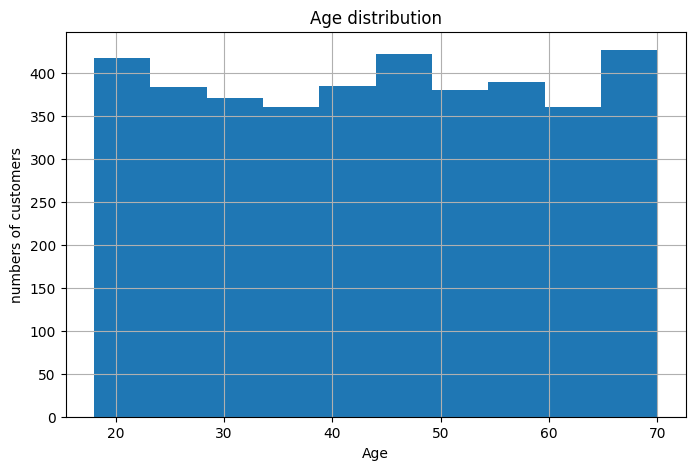

In [41]:
import matplotlib.pyplot as plt
df=pd.read_csv('shopping_trends_updated.csv')
plt.figure(figsize=(8,5))
plt.hist(df['Age'],bins=10)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('numbers of customers')
plt.grid(True)
plt.show()


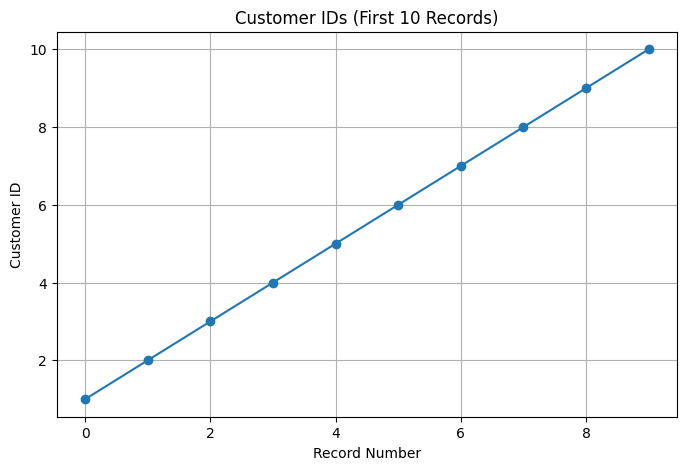

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('shopping_trends_updated.csv')

# Customer ID Graph (first 10 customers)
plt.figure(figsize=(8,5))
plt.plot(df['Customer ID'].head(10), marker='o')
plt.title('Customer IDs (First 10 Records)')
plt.xlabel('Record Number')
plt.ylabel('Customer ID')
plt.grid(True)
plt.show()

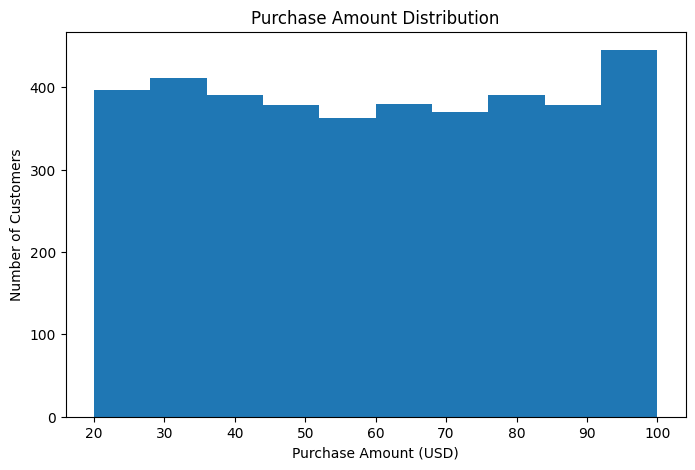

In [43]:
plt.figure(figsize=(8,5))
plt.hist(df['Purchase Amount (USD)'], bins=10)
plt.title('Purchase Amount Distribution')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Number of Customers')
plt.show()

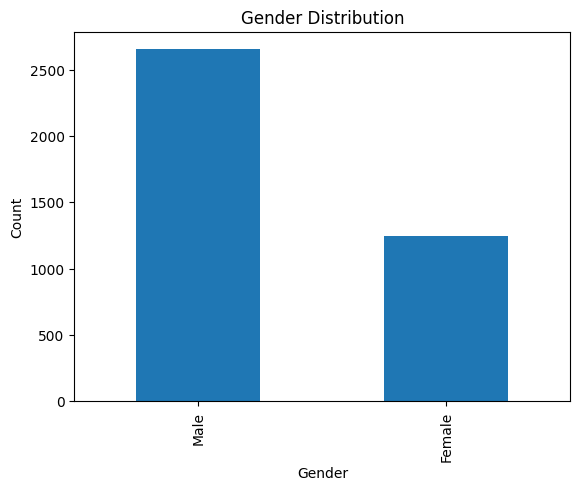

In [44]:
df['Gender'].value_counts().plot(kind='bar')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

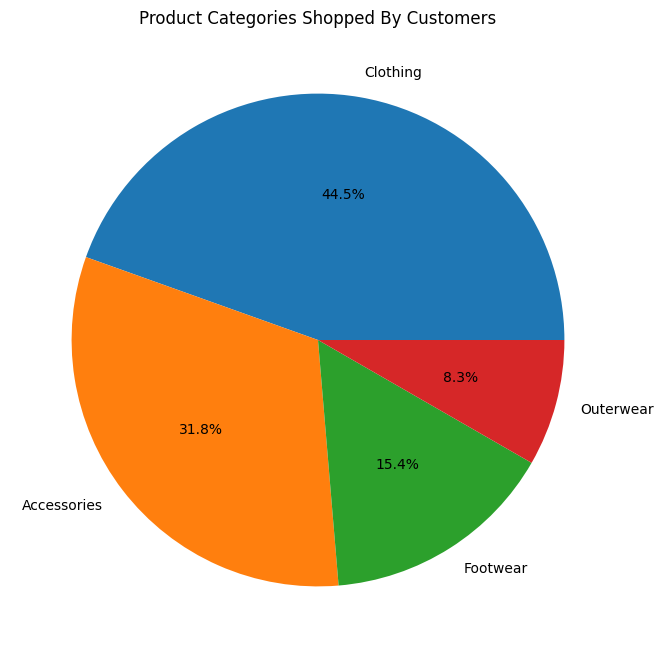

In [45]:
# Count products in each category
category_counts = df['Category'].value_counts()

# Pie Chart
plt.figure(figsize=(8,8))
plt.pie(category_counts,
        labels=category_counts.index,
        autopct='%1.1f%%')

plt.title('Product Categories Shopped By Customers')
plt.show()

In [46]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [47]:
df.to_csv("shopping_trends_updated_feature_enginnering.csv",index=False)

In [48]:
print("Feature Enginnering and Salling Completed !")

Feature Enginnering and Salling Completed !
